# 02 — Feature Engineering & Métrica de Risco

Neste notebook vamos construir:

1. **Features derivadas** dos dados orbitais (volume da casca, densidade espacial, proporção de debris)
2. **Índice de Risco Relativo (IRR)** — nossa métrica principal, de 0 a 10
3. **Dataset final** pronto para o modelo de Machine Learning

### Por que densidade e não distância entre objetos?
Calcular distância real entre 28.000 objetos exigiria física orbital complexa (SGP4 + propagação).
Nossa abordagem é mais simples e igualmente válida academicamente:
quanto mais objetos num volume de espaço, maior a probabilidade de colisão — é o mesmo princípio
usado pelo modelo de Kessler (1978) que previu o efeito cascata de debris.

## 0. Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
OUT_DIR  = Path('../outputs')
PROC_DIR.mkdir(exist_ok=True)

# Carrega dados
gp = pd.read_csv(RAW_DIR / 'gp_leo.csv', low_memory=False)

# Altitude média de cada objeto
gp['ALT_MEDIA'] = (gp['APOAPSIS'] + gp['PERIAPSIS']) / 2

# Garante que colunas numéricas estejam corretas
for col in ['INCLINATION', 'MEAN_MOTION', 'BSTAR', 'APOAPSIS', 'PERIAPSIS']:
    gp[col] = pd.to_numeric(gp[col], errors='coerce')

# Filtra LEO válido (200-2000 km)
gp = gp[(gp['ALT_MEDIA'] >= 200) & (gp['ALT_MEDIA'] <= 2000)].copy()

print(f'Objetos em LEO carregados: {len(gp):,}')
print(f'Colunas disponíveis: {gp.shape[1]}')

Objetos em LEO carregados: 27,994
Colunas disponíveis: 41


## 1. Criando as Faixas de Altitude

Dividimos LEO em camadas de 100 km.

In [2]:
LARGURA_FAIXA = 100  # km
bins = list(range(200, 2100, LARGURA_FAIXA))

# Faixa como STRING simples — evita problema de Categorical
def atribuir_faixa(alt):
    for i in range(len(bins) - 1):
        if bins[i] <= alt < bins[i + 1]:
            return f'{bins[i]}-{bins[i+1]}'
    return None

gp['FAIXA_ALT']  = gp['ALT_MEDIA'].apply(atribuir_faixa)
gp['ALT_CENTRO'] = gp['ALT_MEDIA'].apply(
    lambda alt: next(
        (bins[i] + 50 for i in range(len(bins)-1) if bins[i] <= alt < bins[i+1]),
        np.nan
    )
)

gp = gp.dropna(subset=['FAIXA_ALT'])
ordem_faixas = [f'{b}-{b+LARGURA_FAIXA}' for b in bins[:-1]]

print(f'Faixas criadas: {len(ordem_faixas)}')
print('Primeiras faixas:', ordem_faixas[:5], '...')
print(f'Objetos com faixa atribuída: {len(gp):,}')

Faixas criadas: 18
Primeiras faixas: ['200-300', '300-400', '400-500', '500-600', '600-700'] ...
Objetos com faixa atribuída: 27,994


## 2. Calculando Features por Faixa

In [3]:
R_TERRA = 6371  # km

def volume_casca(alt_min_km: float, espessura_km: float = 100) -> float:
    """Volume de casca esférica: V = (4/3) * pi * (r_ext^3 - r_int^3)"""
    r_int = R_TERRA + alt_min_km
    r_ext = R_TERRA + alt_min_km + espessura_km
    return (4/3) * np.pi * (r_ext**3 - r_int**3)


# Contagens por tipo
contagens = (
    gp.groupby('FAIXA_ALT')['OBJECT_TYPE']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={
        'DEBRIS':      'n_debris',
        'PAYLOAD':     'n_payload',
        'ROCKET BODY': 'n_rocket',
        'UNKNOWN':     'n_unknown',
        'TBA':         'n_tba'
    })
)
for col in ['n_debris', 'n_payload', 'n_rocket', 'n_unknown', 'n_tba']:
    if col not in contagens.columns:
        contagens[col] = 0
contagens['n_total'] = contagens.sum(axis=1)

# Estatísticas numéricas por faixa (FAIXA_ALT é string — sem erro)
stats = gp.groupby('FAIXA_ALT').agg(
    alt_centro    = ('ALT_CENTRO',  'mean'),
    incl_media    = ('INCLINATION', 'mean'),
    incl_std      = ('INCLINATION', 'std'),
    mean_motion_m = ('MEAN_MOTION', 'mean'),
    bstar_medio   = ('BSTAR',       'mean'),
).reset_index()

# Juntar
df = stats.merge(contagens.reset_index(), on='FAIXA_ALT')
df['alt_min'] = df['FAIXA_ALT'].apply(lambda x: int(str(x).split('-')[0]))
df = df.sort_values('alt_min').reset_index(drop=True)

# Volume e densidade
df['volume_km3']        = df['alt_min'].apply(lambda a: volume_casca(a, LARGURA_FAIXA))
df['densidade_por_km3'] = df['n_total'] / df['volume_km3']

# Proporções
df['prop_debris']   = df['n_debris'] / df['n_total'].replace(0, np.nan)
df['n_perigoso']    = df['n_debris'] + df['n_rocket'] + df['n_unknown'] + df['n_tba']
df['prop_perigoso'] = df['n_perigoso'] / df['n_total'].replace(0, np.nan)

print(df[['FAIXA_ALT', 'n_total', 'n_debris', 'n_payload',
          'volume_km3', 'densidade_por_km3', 'prop_debris']].to_string(index=False))

FAIXA_ALT  n_total  n_debris  n_payload   volume_km3  densidade_por_km3  prop_debris
  200-300      144         5         97 5.508905e+10       2.613950e-09     0.034722
  300-400     1460        21       1330 5.676566e+10       2.571978e-08     0.014384
  400-500     7395       121       6863 5.846739e+10       1.264808e-07     0.016362
  500-600     4270       351       3554 6.019427e+10       7.093699e-08     0.082201
  600-700     1879      1025        644 6.194627e+10       3.033274e-08     0.545503
  700-800     2838      2159        404 6.372340e+10       4.453623e-08     0.760747
  800-900     3001      2547        239 6.552567e+10       4.579884e-08     0.848717
 900-1000     1937      1236        403 6.735308e+10       2.875889e-08     0.638100
1000-1100      954       662        193 6.920561e+10       1.378501e-08     0.693920
1100-1200      977       386        519 7.108328e+10       1.374444e-08     0.395087
1200-1300      850       378        349 7.298608e+10       1.1646

## 3. Construindo o IRR (Índice de Risco Relativo)

| Componente | Peso | Justificativa |
|---|---|---|
| Densidade espacial | 50% | Mais objetos = mais chances de encontro |
| Proporção de perigosos | 30% | Debris é incontrolável |
| Inclinação média | 20% | Órbitas polares cruzam mais trajetórias |

In [4]:
def minmax(series: pd.Series) -> pd.Series:
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

df['comp_densidade']  = minmax(df['densidade_por_km3'])
df['comp_debris']     = minmax(df['prop_perigoso'].fillna(0))
df['comp_inclinacao'] = minmax(df['incl_media'].fillna(df['incl_media'].median()))

W_DENSIDADE  = 0.50
W_DEBRIS     = 0.30
W_INCLINACAO = 0.20

df['irr_bruto'] = (
    W_DENSIDADE  * df['comp_densidade']  +
    W_DEBRIS     * df['comp_debris']     +
    W_INCLINACAO * df['comp_inclinacao']
)
df['IRR'] = (df['irr_bruto'] * 10).round(2)

def classificar_risco(irr):
    if irr <= 2:   return 'BAIXO'
    elif irr <= 4: return 'MODERADO'
    elif irr <= 6: return 'ELEVADO'
    elif irr <= 8: return 'ALTO'
    else:          return 'CRITICO'

df['NIVEL_RISCO'] = df['IRR'].apply(classificar_risco)

print('Índice de Risco por Faixa (ordenado por IRR):')
print('=' * 70)
cols = ['FAIXA_ALT', 'n_total', 'n_debris', 'prop_perigoso', 'IRR', 'NIVEL_RISCO']
print(df[cols].sort_values('IRR', ascending=False).to_string(index=False))

Índice de Risco por Faixa (ordenado por IRR):
FAIXA_ALT  n_total  n_debris  prop_perigoso  IRR NIVEL_RISCO
  800-900     3001      2547       0.920360 6.80        ALTO
  700-800     2838      2159       0.857646 6.32        ALTO
 900-1000     1937      1236       0.791946 5.20     ELEVADO
  400-500     7395       121       0.071941 5.00     ELEVADO
  600-700     1879      1025       0.657265 4.82     ELEVADO
1000-1100      954       662       0.797694 4.76     ELEVADO
1500-1600      534       353       0.861423 4.56     ELEVADO
1300-1400      343       241       0.862974 4.54     ELEVADO
1600-1700      210       160       0.871429 4.39     ELEVADO
1800-1900       46        35       0.869565 4.16     ELEVADO
  500-600     4270       351       0.167681 4.11     ELEVADO
1200-1300      850       378       0.589412 4.04     ELEVADO
1700-1800       98        75       0.887755 3.90    MODERADO
1900-2000       45        33       0.888889 3.82    MODERADO
1100-1200      977       386       0.46

## 4. Visualizando o IRR

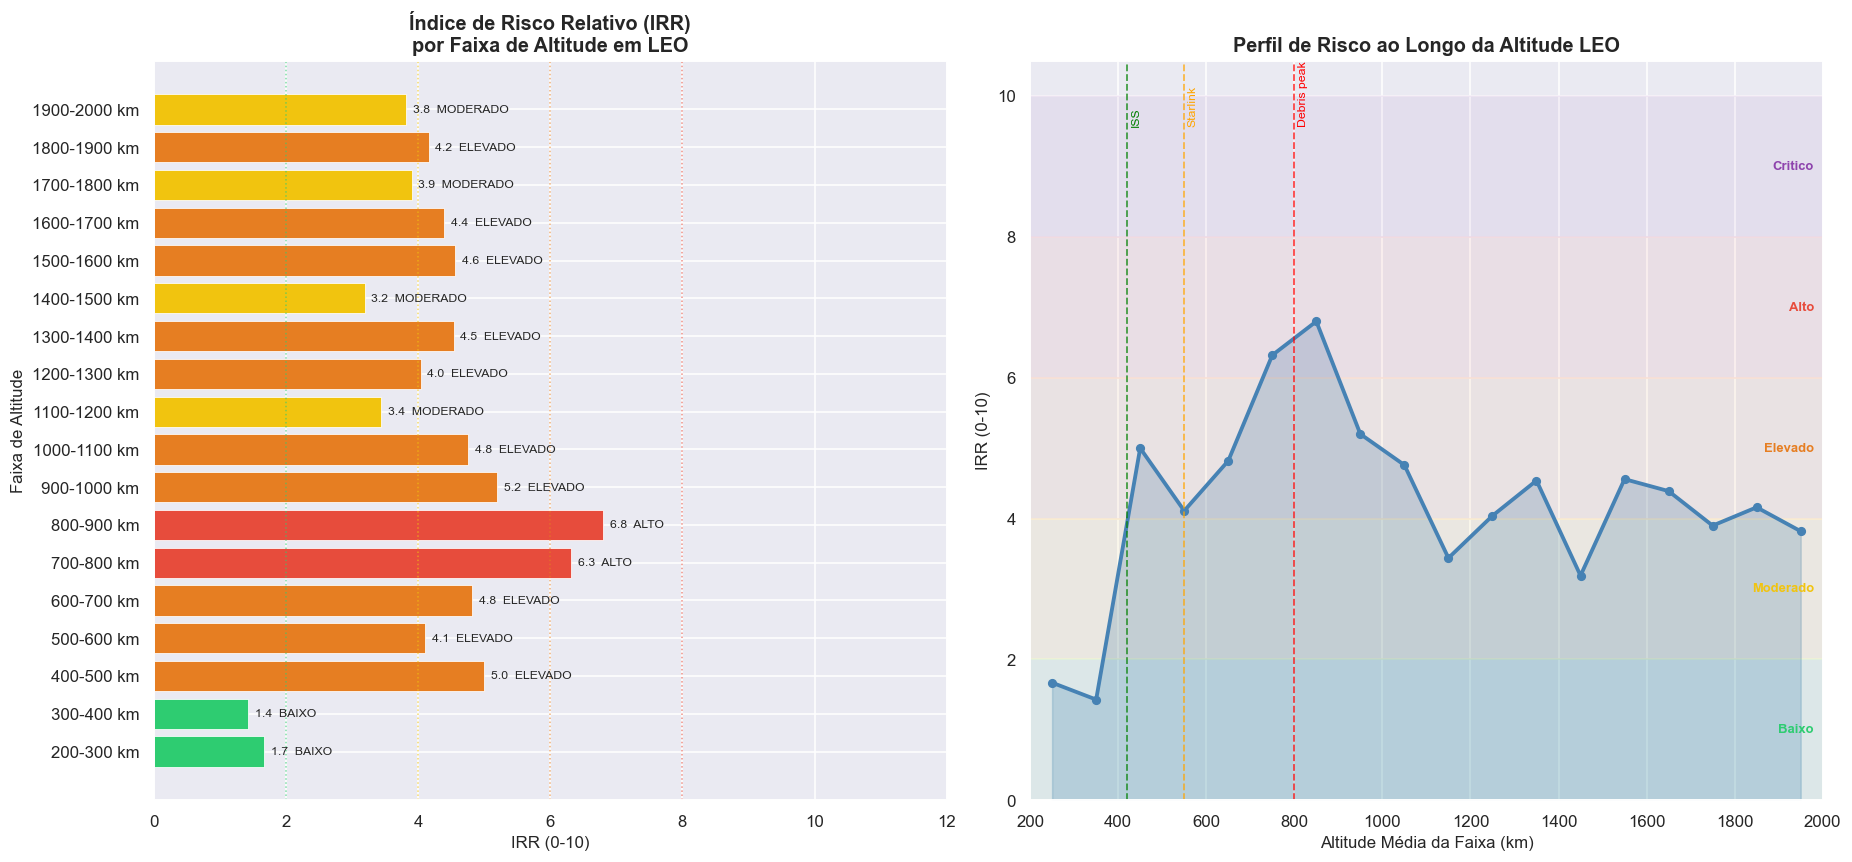

Salvo: outputs/fig07_indice_risco_irr.png


In [5]:
df_plot = df.sort_values('alt_min').copy()

cor_map = {'BAIXO': '#2ecc71', 'MODERADO': '#f1c40f',
           'ELEVADO': '#e67e22', 'ALTO': '#e74c3c', 'CRITICO': '#8e44ad'}
cores = df_plot['NIVEL_RISCO'].map(cor_map)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Barras de IRR
labels_faixa = df_plot['FAIXA_ALT'].astype(str) + ' km'
bars = axes[0].barh(labels_faixa, df_plot['IRR'], color=cores, edgecolor='white', linewidth=0.5)
for bar, irr, nivel in zip(bars, df_plot['IRR'], df_plot['NIVEL_RISCO']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{irr:.1f}  {nivel}', va='center', fontsize=8)
axes[0].set_xlim(0, 12)
for limiar, cor in [(2,'#2ecc71'),(4,'#f1c40f'),(6,'#e67e22'),(8,'#e74c3c')]:
    axes[0].axvline(limiar, color=cor, linestyle=':', linewidth=1, alpha=0.6)
axes[0].set_xlabel('IRR (0-10)', fontsize=11)
axes[0].set_ylabel('Faixa de Altitude', fontsize=11)
axes[0].set_title('Índice de Risco Relativo (IRR)\npor Faixa de Altitude em LEO',
                  fontsize=13, fontweight='bold')

# Perfil de risco
x = df_plot['alt_min'] + 50
axes[1].fill_between(x, df_plot['IRR'], alpha=0.25, color='steelblue')
axes[1].plot(x, df_plot['IRR'], color='steelblue', linewidth=2.5, marker='o', markersize=5)
zonas = [(0,2,'#2ecc71','Baixo'),(2,4,'#f1c40f','Moderado'),
         (4,6,'#e67e22','Elevado'),(6,8,'#e74c3c','Alto'),(8,10,'#8e44ad','Critico')]
for y0, y1, cor, lbl in zonas:
    axes[1].axhspan(y0, y1, alpha=0.07, color=cor)
    axes[1].text(1980, (y0+y1)/2, lbl, fontsize=8.5, color=cor, ha='right', va='center', fontweight='bold')
for alt, lbl, cor in [(420,'ISS','green'),(550,'Starlink','orange'),(800,'Debris peak','red')]:
    axes[1].axvline(alt, color=cor, linestyle='--', linewidth=1.2, alpha=0.7)
    axes[1].text(alt+8, 9.6, lbl, fontsize=8, color=cor, rotation=90)
axes[1].set_xlabel('Altitude Média da Faixa (km)', fontsize=11)
axes[1].set_ylabel('IRR (0-10)', fontsize=11)
axes[1].set_title('Perfil de Risco ao Longo da Altitude LEO',
                  fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 10.5)
axes[1].set_xlim(200, 2000)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_indice_risco_irr.png', bbox_inches='tight')
plt.show()
print('Salvo: outputs/fig07_indice_risco_irr.png')

## 5. Decomposição do IRR por Componente

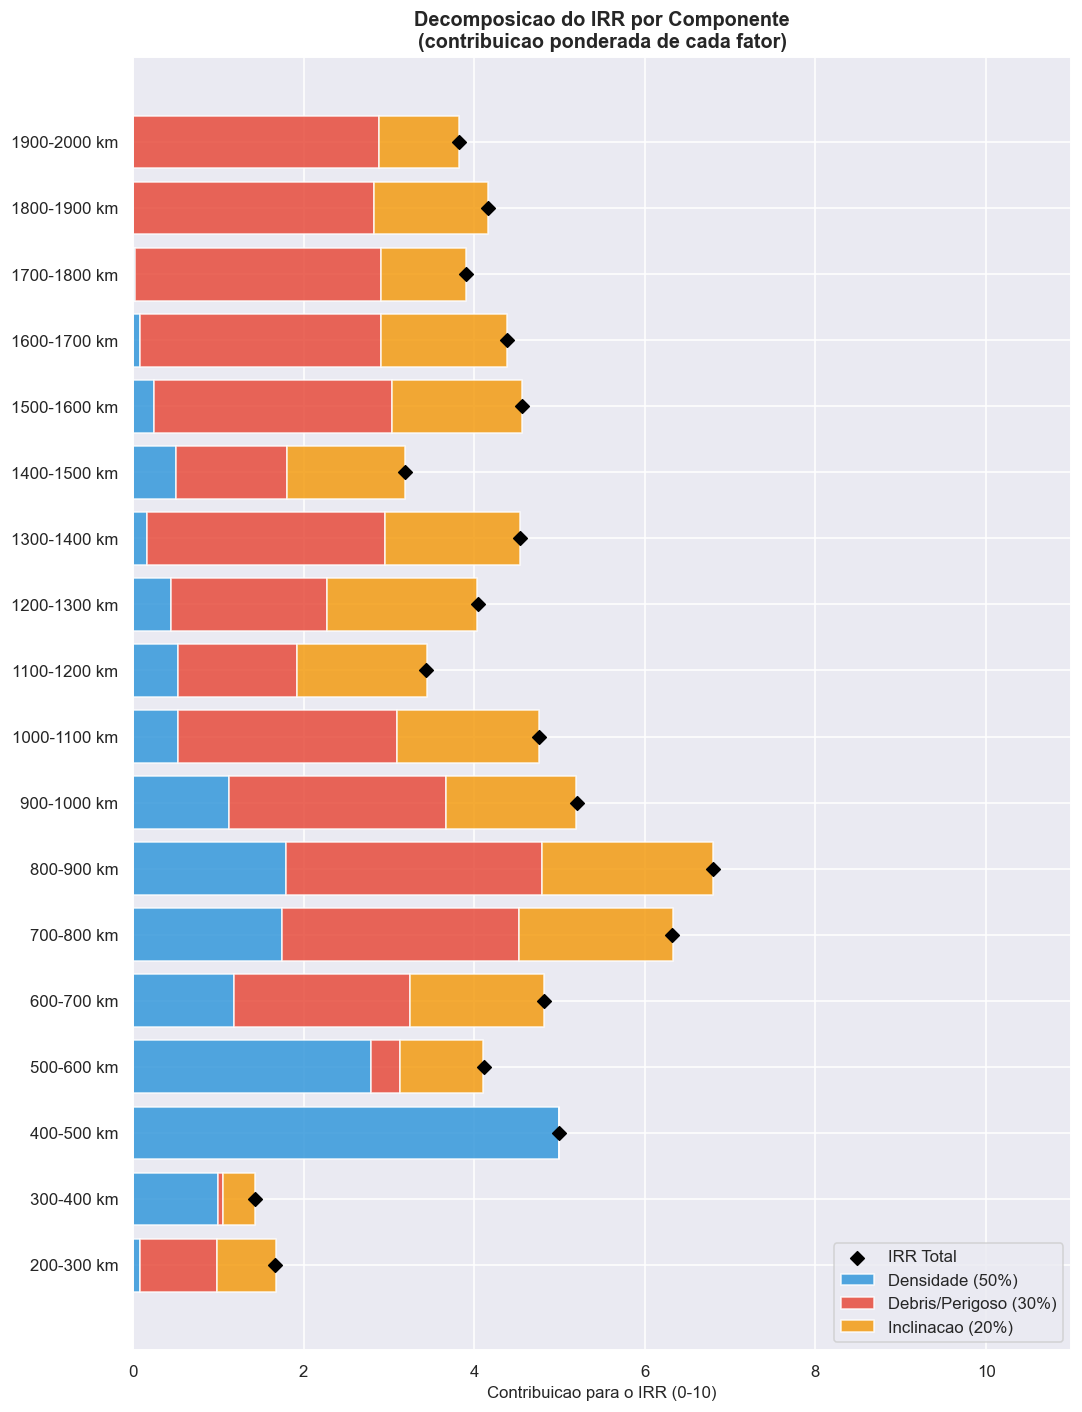

Salvo: outputs/fig08_decomposicao_irr.png


In [6]:
df_plot2 = df.sort_values('alt_min').copy()
df_plot2['contrib_densidade']  = W_DENSIDADE  * df_plot2['comp_densidade']  * 10
df_plot2['contrib_debris']     = W_DEBRIS     * df_plot2['comp_debris']     * 10
df_plot2['contrib_inclinacao'] = W_INCLINACAO * df_plot2['comp_inclinacao'] * 10

faixas_label = df_plot2['FAIXA_ALT'].astype(str) + ' km'

fig, ax = plt.subplots(figsize=(10, 13))
ax.barh(faixas_label, df_plot2['contrib_densidade'],
        label=f'Densidade ({W_DENSIDADE*100:.0f}%)', color='#3498db', alpha=0.85)
ax.barh(faixas_label, df_plot2['contrib_debris'],
        left=df_plot2['contrib_densidade'],
        label=f'Debris/Perigoso ({W_DEBRIS*100:.0f}%)', color='#e74c3c', alpha=0.85)
ax.barh(faixas_label, df_plot2['contrib_inclinacao'],
        left=df_plot2['contrib_densidade'] + df_plot2['contrib_debris'],
        label=f'Inclinacao ({W_INCLINACAO*100:.0f}%)', color='#f39c12', alpha=0.85)
ax.scatter(df_plot2['IRR'], faixas_label,
           color='black', zorder=5, s=40, label='IRR Total', marker='D')
ax.set_xlabel('Contribuicao para o IRR (0-10)', fontsize=11)
ax.set_title('Decomposicao do IRR por Componente\n(contribuicao ponderada de cada fator)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig08_decomposicao_irr.png', bbox_inches='tight')
plt.show()
print('Salvo: outputs/fig08_decomposicao_irr.png')

## 6. Salvando o Dataset Final

In [7]:
colunas_modelo = [
    'FAIXA_ALT', 'alt_min', 'alt_centro',
    'n_total', 'n_debris', 'n_payload', 'n_rocket', 'n_unknown', 'n_perigoso',
    'prop_debris', 'prop_perigoso',
    'volume_km3', 'densidade_por_km3',
    'incl_media', 'incl_std', 'mean_motion_m', 'bstar_medio',
    'comp_densidade', 'comp_debris', 'comp_inclinacao',
    'IRR', 'NIVEL_RISCO'
]

df_final = df[colunas_modelo].sort_values('alt_min').reset_index(drop=True)

output_path = PROC_DIR / 'features_risco_leo.csv'
df_final.to_csv(output_path, index=False)

print(f'Dataset salvo em: {output_path}')
print(f'Shape: {df_final.shape}')
print()
print(df_final[['FAIXA_ALT','n_total','n_debris','densidade_por_km3','IRR','NIVEL_RISCO']].to_string(index=False))

Dataset salvo em: ..\data\processed\features_risco_leo.csv
Shape: (18, 22)

FAIXA_ALT  n_total  n_debris  densidade_por_km3  IRR NIVEL_RISCO
  200-300      144         5       2.613950e-09 1.67       BAIXO
  300-400     1460        21       2.571978e-08 1.43       BAIXO
  400-500     7395       121       1.264808e-07 5.00     ELEVADO
  500-600     4270       351       7.093699e-08 4.11     ELEVADO
  600-700     1879      1025       3.033274e-08 4.82     ELEVADO
  700-800     2838      2159       4.453623e-08 6.32        ALTO
  800-900     3001      2547       4.579884e-08 6.80        ALTO
 900-1000     1937      1236       2.875889e-08 5.20     ELEVADO
1000-1100      954       662       1.378501e-08 4.76     ELEVADO
1100-1200      977       386       1.374444e-08 3.44    MODERADO
1200-1300      850       378       1.164606e-08 4.04     ELEVADO
1300-1400      343       241       4.578583e-09 4.54     ELEVADO
1400-1500     1013       351       1.317859e-08 3.19    MODERADO
1500-1600     

## 7. Resumo Final

In [8]:
print('=' * 60)
print('  RESUMO — FEATURE ENGINEERING')
print('=' * 60)
top3 = df_final.nlargest(3, 'IRR')[['FAIXA_ALT','IRR','NIVEL_RISCO','n_total','n_debris']]
print('\nTop 3 faixas de maior risco:')
print(top3.to_string(index=False))
print(f'\nDistribuicao dos niveis de risco:')
print(df_final['NIVEL_RISCO'].value_counts().to_string())
print(f'\nDataset: data/processed/features_risco_leo.csv')
print(f'Features para o modelo: {len(colunas_modelo)}')
print('\nProximo passo: 03_modelo_ml.ipynb')
print('=' * 60)

  RESUMO — FEATURE ENGINEERING

Top 3 faixas de maior risco:
FAIXA_ALT  IRR NIVEL_RISCO  n_total  n_debris
  800-900 6.80        ALTO     3001      2547
  700-800 6.32        ALTO     2838      2159
 900-1000 5.20     ELEVADO     1937      1236

Distribuicao dos niveis de risco:
NIVEL_RISCO
ELEVADO     10
MODERADO     4
BAIXO        2
ALTO         2

Dataset: data/processed/features_risco_leo.csv
Features para o modelo: 22

Proximo passo: 03_modelo_ml.ipynb
